# CIBUSmod Scenario example:<br/>Revisiting scenarios for organic farming in Sweden

This notebook provides an example run of CIBUSmod using two scenarios up until 2050; 'Base20' and 'Sust50' originally developed by Basnet *et al.* (2023).

**Base20:** A business-as-ususal scenario with assumptions on productivity improvements and population growth   
**Sust50:** A scenario with increased organic production (up to 50% of cropland) coupled with stronger productivity gains, reduced food waste and dietary changes towards less animal-source foods


Basnet, S., Wood, A., Röös, E., Jansson, T., Fetzer, I. & Gordon, L. (2023). Organic agriculture in a low-emission world: exploring combined measures to deliver a sustainable food system in Sweden. *Sustainability Science*, 18(1), 501-519. https://doi.org/10.1007/s11625-022-01279-9

## Set things up

Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


 -----------------------
|   Imported CIBUSmod   |
 -----------------------
commit : 1ba87accf49e1c90724ddb6e32d81e3ee4394674
branch : jk/feed-dist-dev
dirty  : True
remote : https://github.com/SLU-foodsystems/CIBUSmod
    


Instantiate a `Session` object and define scenarios.

In [3]:
years = list(range(2020,2050+1,5))

# Create session
session = cm.Session(
    name = 'example_scenarios',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'Base20',
    scenario_workbooks = 'example_bau',
    years = years
)

# Define scenarios
session.add_scenario(
    name = 'Sust50',
    scenario_workbooks = ['example_bau', 'example_org_circ'],
    years = years
)

A scenario with the name 'Base20' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'Sust50' already exists use .update_scenario() or .remove_scenario() instead.


Define some styling for plots

In [4]:
bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

def annotate_axs(axs, size=10, offset=(-3,1)):
    import string
    for i, ax in enumerate(axs.flatten()):
        ax.annotate(
            f'({string.ascii_lowercase[i % 26]})',
            xy = (0,1), xycoords = 'axes fraction',
            xytext = offset, textcoords = 'offset fontsize',
            fontsize=size, fontweight='bold', va='bottom', ha='right'
        )

def cat7_cmap():
    from matplotlib.colors import ListedColormap
    colors = [
        "#2c7fb8",
        "#f03b20",
        "#31a354",
        "#a1dab4",
        "#fecc5c",
        "#ffffcc",
        "#ffffff",
    ]
    cmap_name = "cat7"
    cmap = ListedColormap(colors, name=cmap_name)
    return cmap

## Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [15]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run
import traceback

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('2026-01-22')]
runs

[('Base20', '2020'),
 ('Base20', '2025'),
 ('Base20', '2030'),
 ('Base20', '2035'),
 ('Base20', '2040'),
 ('Base20', '2045'),
 ('Base20', '2050'),
 ('Sust50', '2020'),
 ('Sust50', '2025'),
 ('Sust50', '2030'),
 ('Sust50', '2035'),
 ('Sust50', '2040'),
 ('Sust50', '2045'),
 ('Sust50', '2050')]

In [16]:
%%time

# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            
            print(f'{scn}, {year} finished successfully in {m}min {s}s')

session.cache.clear()

Base20, 2030 finished successfully in 7min 54s
Base20, 2025 finished successfully in 8min 36s
Base20, 2020 finished successfully in 8min 50s
Base20, 2045 finished successfully in 9min 8s
Sust50, 2020 finished successfully in 9min 10s
Base20, 2040 finished successfully in 9min 11s
Base20, 2035 finished successfully in 9min 14s
Base20, 2050 finished successfully in 9min 19s
Sust50, 2025 finished successfully in 3min 42s
Sust50, 2030 finished successfully in 4min 58s
Sust50, 2035 finished successfully in 5min 24s
Sust50, 2040 finished successfully in 5min 30s
Sust50, 2050 finished successfully in 5min 32s
Sust50, 2045 finished successfully in 5min 35s
CPU times: total: 62.5 ms
Wall time: 15min 4s


## Plot output

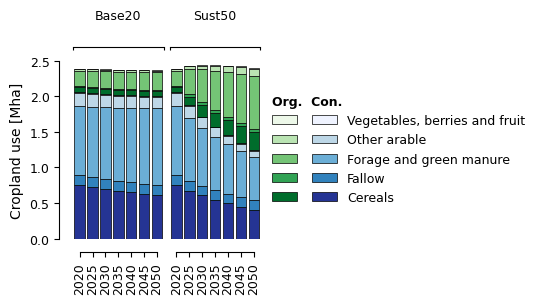

Share of cropland:


prod_system  conventional    organic  total
scn    year                                
Base20 2020     85.995864  14.004136  100.0
       2025     85.707287  14.292713  100.0
       2030     85.449915  14.550085  100.0
       2035     85.220548  14.779452  100.0
       2040     84.999461  15.000539  100.0
       2045     84.787966  15.212034  100.0
       2050     84.596326  15.403674  100.0
Sust50 2020     85.972688  14.027312  100.0
       2025     77.316999  22.683001  100.0
       2030     70.425481  29.574519  100.0
       2035     64.601348  35.398652  100.0
       2040     59.641353  40.358647  100.0
       2045     55.379557  44.620443  100.0
       2050     51.650603  48.349397  100.0

Total cropland area:


prod_system  conventional   organic     total
scn    year                                  
Base20 2020      2.052389  0.334225  2.386614
       2025      2.041814  0.340497  2.382311
       2030      2.030970  0.345826  2.376796
       2035      2.019857  0.350296  2.370152
       2040      2.011828  0.355043  2.366871
       2045      2.005855  0.359876  2.365731
       2050      1.999166  0.364017  2.363183
Sust50 2020      2.051880  0.334785  2.386665
       2025      1.872830  0.549445  2.422275
       2030      1.714575  0.720020  2.434595
       2035      1.572735  0.861788  2.434523
       2040      1.448699  0.980319  2.429018
       2045      1.339403  1.079184  2.418587
       2050      1.239750  1.160512  2.400262

Share "Forage and green manure":


prod_system  conventional    organic
scn    year                         
Base20 2020     47.427311  66.564167
       2025     48.673539  67.243139
       2030     49.832398  67.854640
       2035     50.925467  68.412110
       2040     51.970419  68.947513
       2045     52.967924  69.460073
       2050     53.906887  69.937009
Sust50 2020     47.415672  66.606231
       2025     47.432834  63.898969
       2030     47.502698  63.810343
       2035     47.570540  64.013740
       2040     47.686959  64.287193
       2045     47.882734  64.570104
       2050     48.125465  64.866404

Share "Cereals":


prod_system  conventional    organic
scn    year                         
Base20 2020     36.671787  21.035565
       2025     35.473983  20.678341
       2030     34.372846  20.357921
       2035     33.343800  20.065173
       2040     32.375756  19.789281
       2045     31.465450  19.529265
       2050     30.615406  19.284805
Sust50 2020     36.680129  21.009205
       2025     36.021955  22.335517
       2030     35.358025  22.459853
       2035     34.718266  22.474210
       2040     34.082800  22.449927
       2045     33.436881  22.394971
       2050     32.796868  22.290359

In [17]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':['land_use','crop_group2']})
    .loc[:,(slice(None),'cropland')]
    .droplevel('land_use', axis=1)
    .rename(columns={'Fodder crops':'Forage and green manure'})
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#253494', '#3182bd', '#6baed6','#bdd7e7' , '#eff3ff',
          '#006d2c', '#31a354', '#74c476', '#bae4b3', '#edf8e9']
cust_cmap = ListedColormap(name='X', colors=colors)

# Hide crop group for organic to make nice legend
plot_data_ = plot_data.copy()
plot_data_.columns = \
pd.MultiIndex.from_tuples(
    [(ps,cg) if ps != 'organic' else (ps,' ') for ps,cg in plot_data_.columns],
    names = plot_data_.columns.names
)

fig, ax = plt.subplots(figsize=(5.5,3))
cm.plot.bar(
    plot_data_.droplevel('prod_system', axis=1),
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Cropland use [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap,
    ylim=(0,2.5)
)
ax.legend(
    loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2, frameon=False, reverse=True, fontsize=9,
    columnspacing = 0.1,
    title='Org.  Con.',
    title_fontproperties={'weight': 'bold', 'size': 9},  # Make title bold and adjust size
    alignment="left"  # Align legend text to the left
)

plt.tight_layout()
plt.savefig('figs/mp2025/Fig10.png', dpi=300)
plt.savefig('figs/mp2025/Fig10.pdf', dpi=300)
plt.show()

tab_data = plot_data.T.groupby('prod_system').sum().T
tab_data['total'] = tab_data.sum(axis=1)
tab_data2 = plot_data.T.groupby('prod_system').apply(lambda x: x/x.sum()*100).T.droplevel(0, axis=1)

print('Share of cropland:')
display(tab_data.apply(lambda x: x/x.total*100, axis=1))
print('Total cropland area:')
display(tab_data)
print('Share "Forage and green manure":')
display(tab_data2.xs('Forage and green manure', level='crop_group2', axis=1))
print('Share "Cereals":')
display(tab_data2.xs('Cereals', level='crop_group2', axis=1))

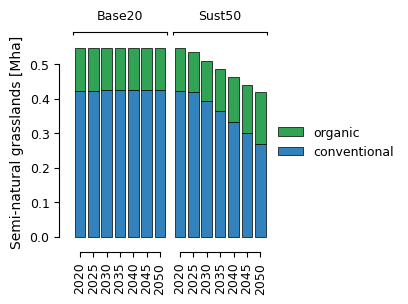

In [18]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':'land_use'})
    .loc[:,(slice(None),'semi-natural grasslands')]
    .droplevel('land_use', axis=1)
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Semi-natural grasslands [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.show()

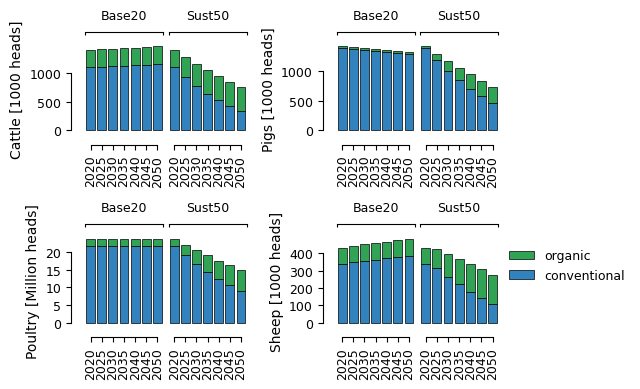

In [19]:
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','prod_system'])

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(2,2, figsize=(6.5,4))

for ax,sp in zip(axs.flatten(),plot_data.drop('horses', axis=1).columns.get_level_values('species').unique()):

    cm.plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **{k:v for k,v in bar_style.items() if k != 'cmap'},
        cmap=cust_cmap,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

for ax in axs.flatten():
    ax.legend().set_visible(False)
ax.legend(loc='upper left', ncol=1, bbox_to_anchor=(1, 1), fontsize=9, frameon=False, reverse=True)

plt.tight_layout()
plt.show()

In [20]:
d = (
    session.get_attr('c','harvest',{'crop':['land_use',None],'prod_system':None})/
    session.get_attr('c','area',{'crop':['land_use',None],'prod_system':None})
).loc[[('Base20','2020'),('Base20','2050'),('Sust50','2050')],'cropland'] / 1_000

display(d.T.xs('conventional', level='prod_system', drop_level=False))
display(d.T.xs('organic', level='prod_system', drop_level=False))

scn                                                  Base20             \
year                                                   2020       2050   
crop                                prod_system                          
Apples                              conventional  18.355543  21.232484   
Barley, spring                      conventional   5.004911   5.958463   
Barley, winter                      conventional   6.363214   7.563890   
Beans, dry                          conventional   1.771584   1.769239   
Broad beans and horse beans, dry    conventional   3.273847   4.099443   
Buckwheat                           conventional   2.123101   1.630593   
Cabbages, cauliflowers and broccoli conventional  21.684473  27.043353   
Carrots                             conventional  67.457069  85.548122   
Cereals for fodder                  conventional   3.494355   3.497617   
Cucumbers                           conventional  61.849075   6.079465   
Currants                            conventional   1.475468   1.498526   
Energy grass                        conventional   4.026097   4.027126   
Fallow                              conventional   2.333873   2.331745   
Green manure                        conventional   4.808164   4.808305   
Herbs                               conventional   4.005472   5.096567   
Lettuce and spinach                 conventional  15.537544  19.689659   
Ley for fodder                      conventional   5.506596   5.520113   
Ley for grazing                     conventional   4.473338   4.500949   
Ley for seed                        conventional   0.650000   0.650000   
Ley not harvested                   conventional   3.971773   3.970272   
Maize (corn)                        conventional   6.098500   6.098854   
Maize for forage and silage         conventional  10.756483  10.729494   
Mixed cereals                       conventional   3.319439   3.289841   
Oats                                conventional   4.622147   5.748362   
Onions                              conventional  51.322429  65.035398   
Other berries                       conventional   1.690413   1.753985   
Other crops for fodder              conventional   4.330885   4.344975   
Other fruit                         conventional   4.562921   4.580192   
Other root vegetables               conventional  34.821039  43.873003   
Other vegetables                    conventional   3.191738   3.849194   
Pears                               conventional  15.663013  15.739243   
Peas, dry                           conventional   3.410903   4.262854   
Peas, green                         conventional   4.401340   4.418503   
Potatoes, starch                    conventional  45.163028  55.109924   
Potatoes, table                     conventional  38.305193  46.620546   
Pumpkins and squash                 conventional  27.251603  34.051304   
Quinoa                              conventional   1.305023   1.305022   
Rapeseed, spring                    conventional   1.836566   2.197602   
Rapeseed, winter                    conventional   3.556179   4.260810   
Rye                                 conventional   6.906408   8.623369   
Short rotation coppice              conventional   4.694347   4.692808   
Strawberries                        conventional   6.877072   6.887168   
Sugar beet                          conventional  76.578712  95.693480   
Triticale, spring                   conventional   3.299437   3.303028   
Triticale, winter                   conventional   5.755315   5.749569   
Wheat, spring                       conventional   4.629986   6.299003   
Wheat, winter                       conventional   7.247108   9.903123   

scn                                                   Sust50  
year                                                    2050  
crop                                prod_system               
Apples                              conventional   23.834385  
Barley, spring                      conventiona

scn                                              Base20                Sust50
year                                               2020       2050       2050
crop                             prod_system                                 
Apples                           organic       8.108282   8.106178   8.075474
Barley, spring                   organic       3.169225   3.262668   4.268732
Barley, winter                   organic       3.980352   4.091599   4.982621
Beans, dry                       organic       1.401542   1.695936   1.852052
Broad beans and horse beans, dry organic       2.472913   2.879240   3.410856
Buckwheat                        organic       0.911753   0.926608   0.830287
Carrots                          organic      58.625395  74.503291  80.536694
Cereals for fodder               organic       3.083970   3.080885   3.129112
Cucumbers                        organic      10.479948  13.307708  14.436093
Energy grass                     organic       3.576094   3.567799   3.687018
Fallow                           organic       2.247322   2.242643   2.316016
Green manure                     organic       4.520138   4.513736   4.927111
Herbs                            organic       0.870744   1.107771   1.203032
Lettuce and spinach              organic       5.837077   7.415305   8.038693
Ley for fodder                   organic       4.727486   4.731591   4.797109
Ley for grazing                  organic       3.822311   3.841530   3.897689
Ley for seed                     organic       0.400000   0.400000   0.400000
Ley not harvested                organic       3.548509   3.546213   3.731903
Maize (corn)                     organic       3.916612   3.913579   3.884146
Mixed cereals                    organic       2.691241   2.714994   3.011821
Oats                             organic       3.038315   3.146750   3.935222
Onions                           organic      25.814843  32.787923  35.486791
Other crops for fodder           organic       3.575969   3.582898   3.603322
Other root vegetables            organic       7.242710   9.201468   9.945466
Other vegetables                 organic       1.349498        NaN   2.748129
Pears                            organic       5.465772   5.469938   5.443692
Peas, dry                        organic       2.522081   2.935164   3.580430
Potatoes, starch                 organic            NaN        NaN  40.529822
Potatoes, table                  organic      26.031042  31.935382  35.366614
Rapeseed, spring                 organic       0.709683   0.941482   1.143702
Rapeseed, winter                 organic       2.135870   2.827119   3.356521
Rye                              organic       3.868454   5.424450   5.950703
Short rotation coppice           organic       4.495953   4.481812   4.621873
Triticale, spring                organic       2.108112   2.106538   2.037806
Triticale, winter                organic       4.232912   4.226415   4.006662
Wheat, spring                    organic       2.913940   3.623104   4.281035
Wheat, winter                    organic       4.432804   5.524458   6.118215

scn     year
Base20  2020     0.771964
        2025     0.757724
        2030     0.745268
        2035     0.735205
        2040     0.724764
        2045     0.714091
        2050     0.705087
Sust50  2020     0.770529
        2025     3.070694
        2030     4.702334
        2035     6.142303
        2040     7.512748
        2045     8.883724
        2050    10.341205
Name: Green manure, dtype: float64

scn     year
Base20  2020    147.876400
        2025    146.608345
        2030    145.307225
        2035    143.962386
        2040    142.767117
        2045    141.665536
        2050    140.497952
Sust50  2020    147.859099
        2025    140.341991
        2030    133.299135
        2035    127.005290
        2040    121.543393
        2045    116.715154
        2050    109.284080
Name: value, dtype: float64

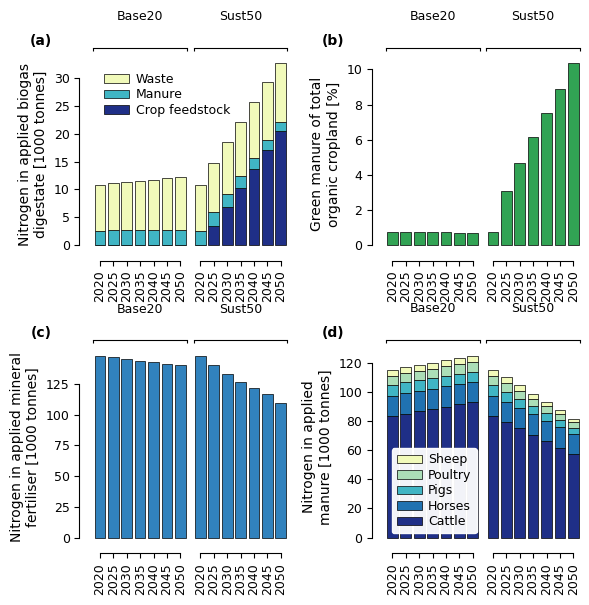

In [21]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

from matplotlib.colors import ListedColormap

plot_data = (
    session.get_attr('w','organic_fertiliser_N','feedstock_type')
    .rename(columns = lambda x: 'Waste' if 'waste' in x else x.capitalize())
    .T.groupby('feedstock_type').sum().T
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied biogas\ndigestate [1000 tonnes]',
    **bar_style
)
legend = ax.legend(
    loc='upper left', bbox_to_anchor=(0, 1),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=False,
    reverse=True
)
# plt.show()

plot_data = session.get_attr('c','area',{'prod_system':None,'crop':['land_use',None]}).loc[:,('organic','cropland')].apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

colors = ['#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Green manure of total\norganic cropland [%]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
# plt.show()

display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.mineral_N','none')
)/1_000_000

colors = ['#3182bd']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied mineral\nfertiliser [1000 tonnes]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend().set_visible(False)
# plt.show()
display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.manure_N','species')
    .rename(columns = lambda x: x.capitalize())
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied\nmanure [1000 tonnes]',
    **bar_style
)
# ax.legend(loc='lower left', bbox_to_anchor=(0, 0), ncol=1, fontsize=9, frameon=True, reverse=True)
legend = ax.legend(
    loc='lower left', bbox_to_anchor=(0, 0),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=True,
    reverse=True
)
legend.get_frame().set_edgecolor('white')
# legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
# plt.show()

plt.tight_layout()
annotate_axs(axs)
plt.savefig('figs/mp2025/Fig12.png', dpi=300)
plt.savefig('figs/mp2025/Fig12.pdf', dpi=300)
plt.show()

In [22]:
session.get_attr('c','fertiliser.mineral_N','prod_system').add(
    session.get_attr('c','fertiliser.manure_N','prod_system')+session.get_attr('c','fertiliser.organic_N','prod_system'),
    fill_value=0
)/1_000_000

prod_system  conventional    organic
scn    year                         
Base20 2020    251.216309  22.380634
       2025    251.725189  22.779019
       2030    252.024326  23.130779
       2035    252.077607  23.432826
       2040    252.362547  23.755621
       2045    252.769379  24.086411
       2050    252.922857  24.371094
Sust50 2020    251.182298  22.393498
       2025    229.838914  35.056053
       2030    209.874256  46.259880
       2035    191.390907  56.419445
       2040    174.687688  65.624193
       2045    159.494754  73.849439
       2050    146.345554  77.086232

Base20, 2020
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,39.124979,0.877399,71.97407,4.727111,116.703559
Organic\ncropland,13.702136,41.118115,NaN,3.288493,58.108744


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,32.945700,0.738826,60.606707,3.980526
Organic\ncropland,23.445311,70.355967,NaN,5.626840


Sust50, 2050
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,23.906989,0.098449,88.002374,0.000000,112.007812
Organic\ncropland,8.298033,26.519445,NaN,28.086436,62.903914


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,21.110379,0.086933,77.707964,0.000000
Organic\ncropland,12.952637,41.394963,NaN,43.840924


C:\Users\jnka0003\AppData\Local\Temp\ipykernel_30792\95059158.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


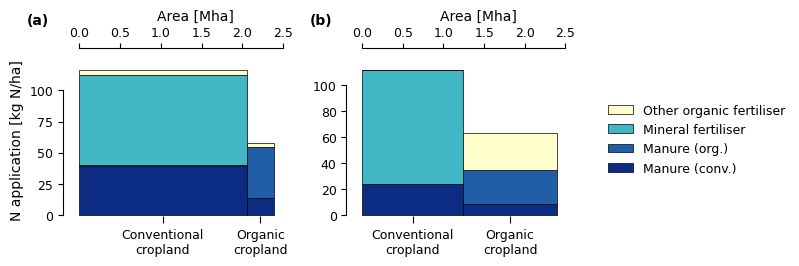

In [23]:
from matplotlib.colors import ListedColormap
colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(1,2, figsize=(6.7,2), gridspec_kw={'wspace' : 0.2})

i=0
for scn, year in [('Base20','2020'),('Sust50','2050')]:

    ax = axs[i]
    
    mi = (
        session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    ma = (
        session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
        .unstack()
        .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
    )
    
    oo = (
        session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    
    ar = (
        session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
    )
    
    plot_data = pd.concat([
        ma.div(ar, axis=0),
        mi.div(ar, axis=0).rename('Mineral fertiliser'),
        oo.div(ar, axis=0).rename('Other organic fertiliser'),
        ar.rename('area')/1_000_000
    ], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})
    
    cm.plot.marimekko(
        plot_data.fillna(0),
        ax=ax,
        x_column='area',
        cmap=cust_cmap,
        sort_categories=False,
        xlim_pad = 0.2,
        ylim_pad = 0.05,
        xcategorylabels_rotation=0,
        xcategorylabels_halign='center',
        ylabel='N application [kg N/ha]' if i==0 else '',
        xlabel='Area [Mha]',
        ylabel_fontsize=10,
        xlabel_fontsize=10,
        ticklabels_fontsize=9,
        xcategorylabels_fontsize=9
    )

    if i == 1:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
    else:
        ax.legend().set_visible(False)

    table_data = plot_data.drop('area', axis=1)
    table_data['total'] = table_data.sum(axis=1)
    pstr = ', '.join((scn,year))
    print(pstr)
    print('-'*len(pstr))
    display(table_data)
    display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)
    i += 1

plt.tight_layout()
annotate_axs(axs, offset=(-2,2.5))
plt.savefig('figs/mp2025/Fig11.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/mp2025/Fig11.pdf', dpi=300, bbox_inches='tight')
plt.show()

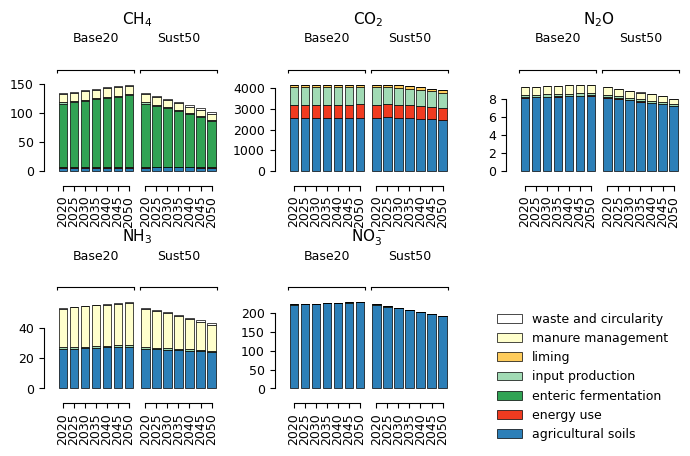

In [24]:
to_comp = {
    'CO2' : 1,
    'CH4bio' : 1,
    'CH4fos' : 1,
    'N2O' : 1,
    'N2O-N' : (44/28),
    'NH3' : 1,
    'NH3-N' : (17/14),
    'NO3-N' : (62/14),
    'NO3' : (62/14),
    'NOx' : 1,
    'NH4' : 1,
    'PO4' : 1,
    'K' : 1
}

to_comp_names = {
    'N2O' : 'N$_2$O',
    'CO2' : 'CO$_2$',
    'CH4bio' : 'CH$_4$',
    'CH4fos' : 'CH$_4$',
    'N2O-N' : 'N$_2$O',
    'NH3' : 'NH$_3$',
    'NH3-N' : 'NH$_3$',
    'NO3-N' : 'NO$_3^-$',
    'NO3' : 'NO$_3^-$',
    'NOx' : 'NO$_X$',
    'NH4' : 'NH$_4$',
    'PO4' : 'PO$_4^{3-}$',
    'K' : 'K'
}

ems = (
    cm.impact.get_emissions(session)
    .drop(['NOx-N','CO2bio','CO','N2','NOx','K','NH4','PO4','NMVOC','PM','SO2'], level='compound', axis=1)
)

plot_data = (
    ems
    .mul([to_comp[cp] for cp in ems.columns.get_level_values('compound')], axis=1)
    .rename(to_comp_names, axis=1)
    .T.groupby(['compound','process']).sum().T
    .stack().unstack().fillna(0)
)/1_000_000

fig, axs = plt.subplots(2,3, figsize=(7,4.5))
for i, cmp in enumerate(plot_data.columns.unique('compound')):
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[:,cmp],
        group_levels='scn',
        ax=ax,
        **{k:v for k,v in bar_style.items() if k!='cmap'},
        cmap=cat7_cmap()
    )
    ax.set_title(cmp, fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax = axs.flatten()[-1]
ax.legend(handles, labels, fontsize=9, frameon=False, reverse=True)
ax.axis('off')

for ax in axs.flatten()[:-1]:
    ax.legend().set_visible(False)

plt.tight_layout()
plt.savefig('figs/mp2025/Fig13.png', dpi=300)
plt.savefig('figs/mp2025/Fig13.pdf', dpi=300)
plt.show()

tab_data = plot_data.T.groupby('compound').sum().T
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

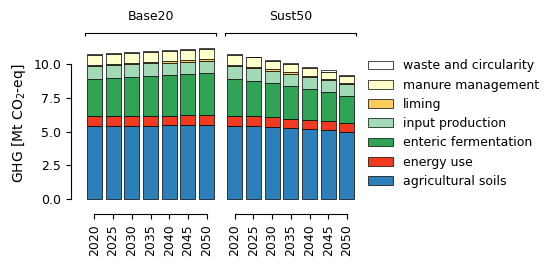

In [25]:
ghg = (
    cm.impact.get_GHG(session)
    .T.groupby('process').sum().T
) / 1_000_000_000 # [Mt]
fig, ax = plt.subplots(1,1, figsize=(3.5,2))
cm.plot.bar(
    ghg,
    group_levels='scn',
    ax=ax,
    ylabel='GHG [Mt CO$_2$-eq]',
    **{k:v for k,v in bar_style.items() if k!='cmap'},
    cmap=cat7_cmap()
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
plt.show()

tab_data = ghg.sum(axis=1).to_frame()
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

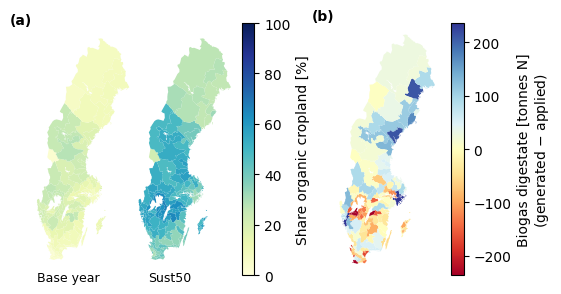

Share organic per region: 22-66%


In [26]:
plot_data1 = (
    session.get_attr('c','area',{'crop':'land_use','region':None,'prod_system':None})
    .loc[:,'cropland']
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100).xs('organic', level='prod_system')
    .droplevel(0).T
)

fig, axs = plt.subplots(1,3, figsize=(5.5,3), gridspec_kw={'width_ratios' : [1,1.25, 2.2], 'wspace' : 0})

ax=axs[0]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2020')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Base year', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

ax=axs[1]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2050')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Sust50', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Share organic cropland [%]', fontsize=10)

plot_data2 = (session.get_attr('w','organic_fertiliser_N','region').loc[('Sust50','2050')] - session.get_attr('c','fertiliser.organic_N','region').loc[('Sust50','2050')]) / 1_000

ax=axs[2]
cm.plot.map_from_series(
    plot_data2,
    ax = ax,
    cmap = 'RdYlBu',
    vmax = plot_data2.abs().quantile(0.95),
    vmin = -plot_data2.abs().quantile(0.95),
    legend = False
)
ax.axis('off')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Biogas digestate [tonnes N]\n(generated $\minus$ applied)', fontsize=10)

plt.tight_layout()
annotate_axs(axs[[0,2]], offset=(0,0))
plt.savefig('figs/mp2025/Fig14.png', bbox_inches='tight', dpi=300)
plt.savefig('figs/mp2025/Fig14.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"Share organic per region: {plot_data1.loc[('Sust50','2050')].min():.0f}-{plot_data1.loc[('Sust50','2050')].max():.0f}%")

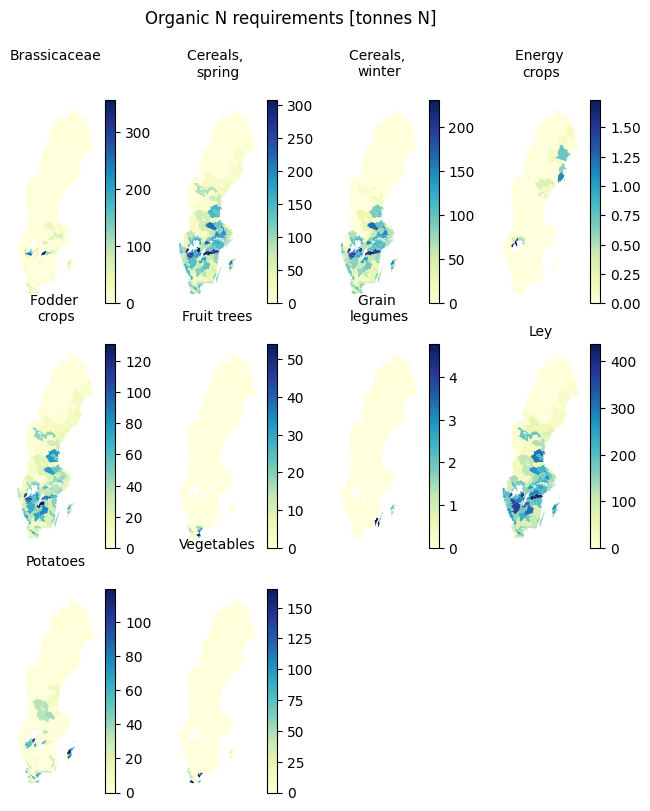

In [27]:
plot_data = (
    session.get_attr('c','fertiliser.TAN_req',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    # .T.groupby('region')
    # .apply(lambda x: x/x.sum()*100)
    # .droplevel(0).T
)/1000

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Organic N requirements [tonnes N]')
plt.show()

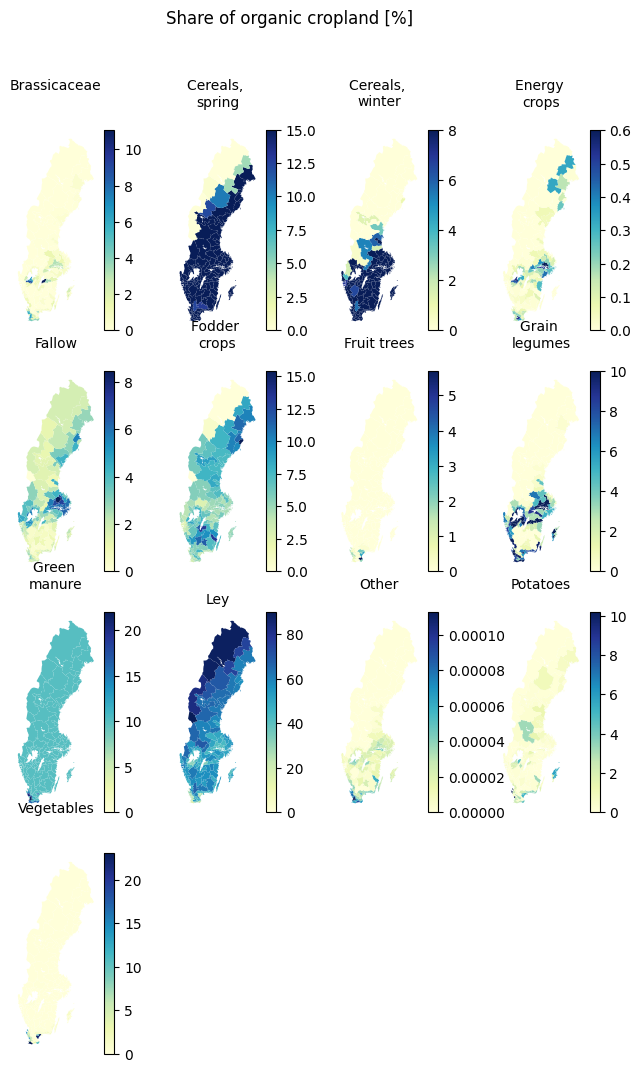

In [28]:
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100)
    .droplevel(0).T
)

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    vmin=0,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Share of organic cropland [%]')
plt.show()

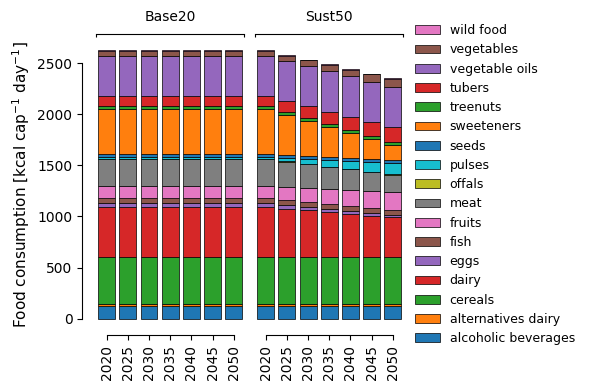

In [29]:
plot_data = (
    session.get_attr('d', 'nutrient_supply', ['nutrient','food_group'])
    .loc[:,'kcal']
    .div(
        session.get_attr('d','population')*1_000_000,
        axis=0
    )
    .div(365.25)
)

fig,ax = plt.subplots(figsize=(6,4))
cm.plot.bar(
    plot_data,
    group_levels='scn',
    ylabel='Food consumption [kcal cap$^{-1}$ day$^{-1}$]'
)

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.tight_layout()
plt.show()

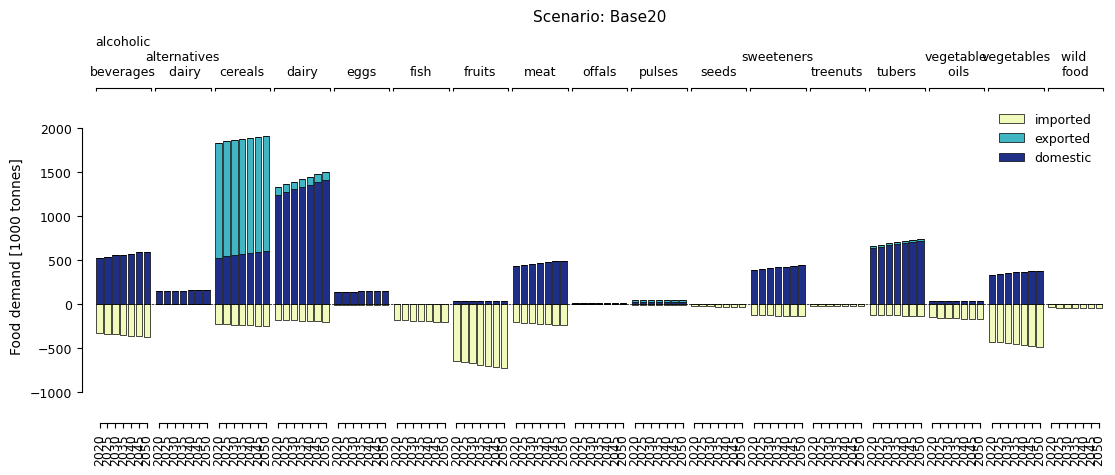

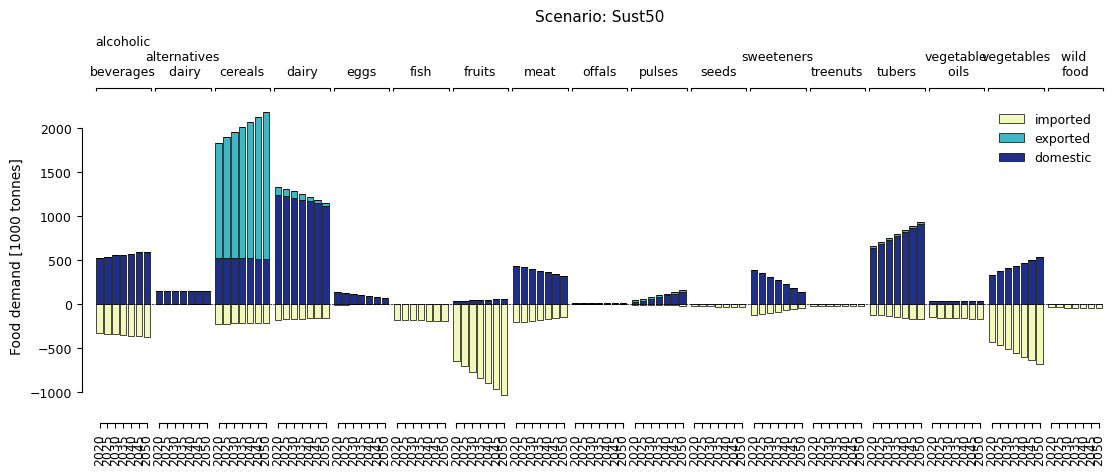

In [30]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

for scn in session.scenarios():
    fig, ax = plt.subplots(figsize=(13,4))
    cm.plot.bar(plot_data.loc[scn], group_levels='food_group', grouptitle=f'Scenario: {scn}', ax=ax,
                ylim=(-1200, 2300), totmarker='none', ylabel='Food demand [1000 tonnes]', **bar_style)
    plt.show()